In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.7 MB/s eta 0:00:00


In [ ]:
import os

ROOT_PATH = "/content/drive/MyDrive/ich"

RSNA_TRAIN_CSV = os.path.join(ROOT_PATH, "stage_2_train.csv")
RSNA_TRAIN_IMG_DIR = os.path.join(ROOT_PATH, "rsna_subset_6gb")

print("CSV exists:", os.path.exists(RSNA_TRAIN_CSV))
print("Image folder exists:", os.path.exists(RSNA_TRAIN_IMG_DIR))


CSV exists: True
Image folder exists: True


In [ ]:
import pandas as pd

df_rsna = pd.read_csv(RSNA_TRAIN_CSV)

print("Original CSV shape:", df_rsna.shape)
df_rsna.head()


Original CSV shape: (4516842, 2)


,ID,Label
0,ID_12cadc6af_epidural,0
1,ID_12cadc6af_intraparenchymal,0
2,ID_12cadc6af_intraventricular,0
3,ID_12cadc6af_subarachnoid,0
4,ID_12cadc6af_subdural,0


In [ ]:


# ==============================
# SEGMENTATION DATASET
# ==============================
SEGMENTATION_DATASET_PATH = os.path.join(
    ROOT_PATH,
    "computed-tomography-ct-images",
    "computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.0.0"
)

PATIENTS_CT_DIR = os.path.join(
    SEGMENTATION_DATASET_PATH,
    "Patients_CT"
)

print("RSNA CSV exists:", os.path.exists(RSNA_TRAIN_CSV))
print("RSNA image folder exists:", os.path.exists(RSNA_TRAIN_IMG_DIR))
print("Segmentation dataset exists:", os.path.exists(PATIENTS_CT_DIR))


RSNA CSV exists: True
RSNA image folder exists: True
Segmentation dataset exists: True


In [ ]:
# Get available DICOM image IDs from subset
available_images = set(
    f.replace(".dcm", "")
    for f in os.listdir(RSNA_TRAIN_IMG_DIR)
    if f.endswith(".dcm")
)

print("Images available in subset:", len(available_images))

# Extract base image_id from CSV
df_rsna["image_id"] = df_rsna["ID"].apply(
    lambda x: "_".join(x.split("_")[:-1])
)

# Filter CSV to match subset images
df_rsna = df_rsna[df_rsna["image_id"].isin(available_images)]

print("Filtered CSV shape:", df_rsna.shape)


Images available in subset: 1200
Filtered CSV shape: (7200, 3)


hemorrhage_type
any                 161
epidural              6
intraparenchymal     54
intraventricular     32
subarachnoid         53
subdural             81
Name: Label, dtype: int64


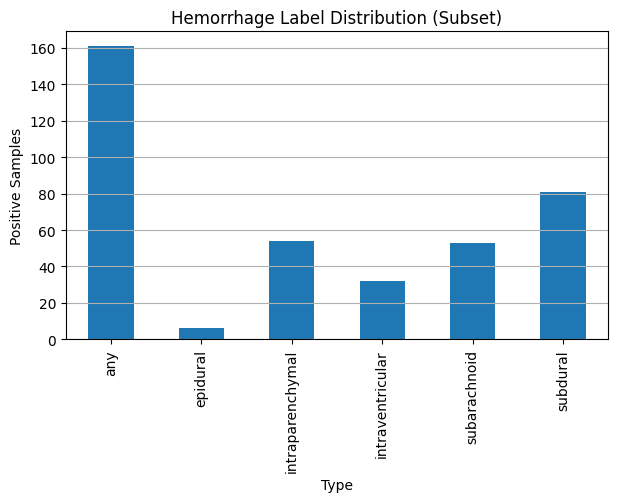

In [ ]:
# Extract hemorrhage type
df_rsna["hemorrhage_type"] = df_rsna["ID"].apply(
    lambda x: x.split("_")[-1]
)

label_distribution = df_rsna.groupby("hemorrhage_type")["Label"].sum()
print(label_distribution)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
label_distribution.plot(kind="bar")
plt.title("Hemorrhage Label Distribution (Subset)")
plt.ylabel("Positive Samples")
plt.xlabel("Type")
plt.grid(axis="y")
plt.show()


In [ ]:
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Libraries imported successfully")


Libraries imported successfully


In [ ]:
# # Extract hemorrhage type
# df_rsna["hemorrhage_type"] = df_rsna["ID"].apply(lambda x: x.split("_")[-1])

# label_distribution = df_rsna.groupby("hemorrhage_type")["Label"].sum()
# print(label_distribution)

# import matplotlib.pyplot as plt

# plt.figure(figsize=(7,4))
# label_distribution.plot(kind="bar")
# plt.title("RSNA Hemorrhage Label Distribution (Subset)")
# plt.ylabel("Positive Samples")
# plt.xlabel("Hemorrhage Type")
# plt.grid(axis="y")
# plt.show()


In [ ]:
!pip install pydicom

Loading: /content/drive/MyDrive/ich/rsna_subset_6gb/ID_5ef15295b.dcm
File exists: True


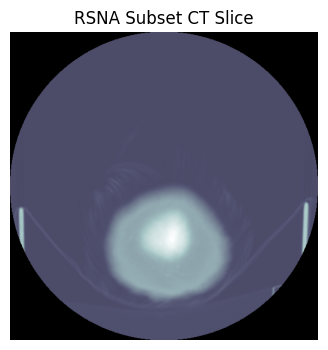

In [ ]:
import pydicom as dcm

row = df_rsna.sample(1).iloc[0]
image_id = row["image_id"]

dcm_path = os.path.join(RSNA_TRAIN_IMG_DIR, image_id + ".dcm")

print("Loading:", dcm_path)
print("File exists:", os.path.exists(dcm_path))

ds = dcm.dcmread(dcm_path)
img = ds.pixel_array

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="bone")
plt.title("RSNA Subset CT Slice")
plt.axis("off")
plt.show()



In [ ]:
# ============================================================
# 4. SEGMENTATION DATASET LOADING (COLAB)
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("\n========== SEGMENTATION DATASET ==========")

SEG_BASE_PATH = os.path.join(
    ROOT_PATH,
    "computed-tomography-ct-images",
    "computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.0.0"
)

SEG_CSV = os.path.join(SEG_BASE_PATH, "hemorrhage_diagnosis.csv")

print("Segmentation base path exists:", os.path.exists(SEG_BASE_PATH))
print("Segmentation CSV exists:", os.path.exists(SEG_CSV))

df_seg = pd.read_csv(SEG_CSV)

print("Segmentation CSV loaded successfully")
print("Shape:", df_seg.shape)
print("Columns:", df_seg.columns.tolist())

df_seg.head()



========== SEGMENTATION DATASET ==========
Segmentation base path exists: True
Segmentation CSV exists: True
Segmentation CSV loaded successfully
Shape: (2501, 9)
Columns: ['PatientNumber', 'SliceNumber', 'Intraventricular', 'Intraparenchymal', 'Subarachnoid', 'Epidural', 'Subdural', 'No_Hemorrhage', 'Fracture_Yes_No']


,PatientNumber,SliceNumber,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,No_Hemorrhage,Fracture_Yes_No
0,49,1,0,0,0,0,0,1,0
1,49,2,0,0,0,0,0,1,0
2,49,3,0,0,0,0,0,1,0
3,49,4,0,0,0,0,0,1,0
4,49,5,0,0,0,0,0,1,0



Hemorrhage Presence Distribution:
Has_Hemorrhage
0    2183
1     318
Name: count, dtype: int64


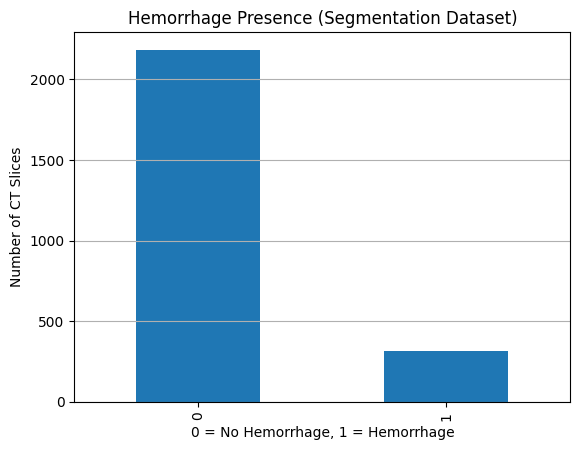

In [ ]:
# ============================================================
# 5. SEGMENTATION LABEL UNDERSTANDING
# ============================================================

# Create binary hemorrhage label
df_seg["Has_Hemorrhage"] = (df_seg["No_Hemorrhage"] == 0).astype(int)

print("\nHemorrhage Presence Distribution:")
print(df_seg["Has_Hemorrhage"].value_counts())

df_seg["Has_Hemorrhage"].value_counts().plot(
    kind="bar",
    title="Hemorrhage Presence (Segmentation Dataset)"
)
plt.xlabel("0 = No Hemorrhage, 1 = Hemorrhage")
plt.ylabel("Number of CT Slices")
plt.grid(axis="y")
plt.show()


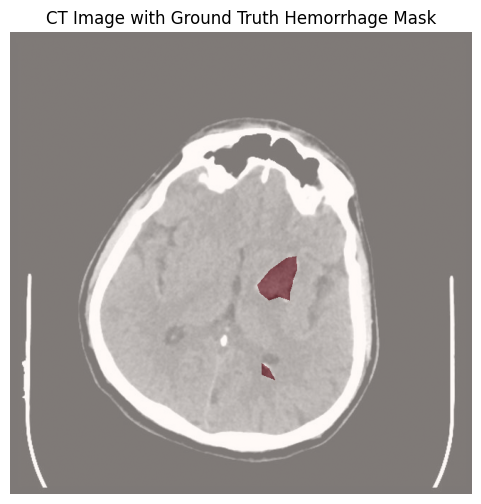


✅ Data Loading / Data Understanding & Exploration completed successfully


In [ ]:
# ============================================================
# 6. SEGMENTATION IMAGE & MASK VISUALIZATION
# ============================================================

# Pick one hemorrhage-positive slice
row = df_seg[df_seg["Has_Hemorrhage"] == 1].sample(1).iloc[0]

patient_id = f"{int(row['PatientNumber']):03d}"
slice_id = row["SliceNumber"]

img_path = os.path.join(
    SEG_BASE_PATH,
    "Patients_CT",
    patient_id,
    "brain",
    f"{slice_id}.jpg"
)

mask_path = os.path.join(
    SEG_BASE_PATH,
    "Patients_CT",
    patient_id,
    "brain",
    f"{slice_id}_HGE_Seg.jpg"
)

ct_img = cv2.imread(img_path)
ct_img = cv2.cvtColor(ct_img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6,6))
plt.imshow(ct_img)
plt.imshow(mask, cmap="Reds", alpha=0.5)
plt.title("CT Image with Ground Truth Hemorrhage Mask")
plt.axis("off")
plt.show()

print("\n✅ Data Loading / Data Understanding & Exploration completed successfully")


In [ ]:
# ============================================================
# SECTION 3: DATA PREPROCESSING (CLASSIFICATION + SEGMENTATION)
# ============================================================

import numpy as np
import cv2
import pydicom as dcm
import tensorflow as tf

# ============================================================
# 1. CLASSIFICATION PREPROCESSING (RSNA - DICOM)
# ============================================================

def window_image(img, window_center, window_width):
    """
    Apply windowing to CT image
    """
    min_val = window_center - window_width // 2
    max_val = window_center + window_width // 2
    img = np.clip(img, min_val, max_val)
    return img


def normalize_image(img):
    """
    Normalize image to [0,1]
    """
    img = img.astype(np.float32)
    img -= img.min()
    img /= (img.max() + 1e-8)
    return img


def preprocess_dicom_for_classification(dcm_path, img_size=224):
    """
    Full preprocessing pipeline for RSNA classification
    """
    ds = dcm.dcmread(dcm_path)
    img = ds.pixel_array.astype(np.float32)

    # Brain window
    img = window_image(img, window_center=40, window_width=80)

    # Normalize
    img = normalize_image(img)

    # Resize
    img = cv2.resize(img, (img_size, img_size))

    # Convert to 3-channel
    img = np.stack([img] * 3, axis=-1)

    return img


# ============================================================
# 2. SEGMENTATION PREPROCESSING (CT + MASK)
# ============================================================

def preprocess_ct_image(img_path, img_size=256):
    """
    Load and preprocess CT image for segmentation
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0

    return img


def preprocess_mask(mask_path, img_size=256):
    """
    Load and preprocess hemorrhage mask
    """
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (img_size, img_size))

    # Binary mask
    mask = (mask > 0).astype(np.float32)

    # Add channel dimension
    mask = np.expand_dims(mask, axis=-1)

    return mask


# ============================================================
# 3. SANITY CHECK (VERY IMPORTANT)
# ============================================================

print("\nRunning preprocessing sanity checks...")

# ---- Classification check ----
sample_full_id = df_rsna.sample(1)["ID"].values[0]
sample_image_id = "_".join(sample_full_id.split("_")[:2])
sample_dcm_path = os.path.join(
    RSNA_TRAIN_IMG_DIR, f"{sample_image_id}.dcm"
)

cls_img = preprocess_dicom_for_classification(sample_dcm_path)
print("Classification image shape:", cls_img.shape)

# ---- Segmentation check ----
row = df_seg[df_seg["Has_Hemorrhage"] == 1].sample(1).iloc[0]
patient_id = f"{int(row['PatientNumber']):03d}"
slice_id = row["SliceNumber"]

img_path = os.path.join(
    SEG_BASE_PATH,
    "Patients_CT",
    patient_id,
    "brain",
    f"{slice_id}.jpg"
)

mask_path = os.path.join(
    SEG_BASE_PATH,
    "Patients_CT",
    patient_id,
    "brain",
    f"{slice_id}_HGE_Seg.jpg"
)

seg_img = preprocess_ct_image(img_path)
seg_mask = preprocess_mask(mask_path)

print("Segmentation image shape:", seg_img.shape)
print("Segmentation mask shape :", seg_mask.shape)

print("\n✅ Data Preprocessing completed successfully")



Running preprocessing sanity checks...
Classification image shape: (224, 224, 3)
Segmentation image shape: (256, 256, 3)
Segmentation mask shape : (256, 256, 1)

✅ Data Preprocessing completed successfully


In [ ]:
# ============================================================
# CLASSIFICATION DATA SPLITTING & LOADER (RSNA)
# ============================================================

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence

# Keep only 'any' label for detection (binary)
df_cls = df_rsna[df_rsna["hemorrhage_type"] == "any"].copy()

df_cls["image_id"] = df_cls["ID"].apply(
    lambda x: "_".join(x.split("_")[:2])
)

labels = df_cls.set_index("image_id")["Label"]
image_ids = labels.index.values

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    image_ids,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Classification train samples:", len(X_train))
print("Classification val samples  :", len(X_val))


Classification train samples: 960
Classification val samples  : 240


In [ ]:
class ClassificationSequence(Sequence):
    def __init__(self, image_ids, labels, img_dir, batch_size=16, shuffle=True):
        self.image_ids = image_ids
        self.labels = labels
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_ids) / self.batch_size))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.image_ids))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_ids = self.image_ids[batch_idx]

        X = []
        y = []

        for img_id in batch_ids:
            dcm_path = os.path.join(self.img_dir, f"{img_id}.dcm")
            img = preprocess_dicom_for_classification(dcm_path)
            X.append(img)
            y.append(self.labels.loc[img_id])

        return np.array(X), np.array(y)


In [ ]:
train_cls_gen = ClassificationSequence(
    X_train, y_train, RSNA_TRAIN_IMG_DIR, batch_size=16
)

val_cls_gen = ClassificationSequence(
    X_val, y_val, RSNA_TRAIN_IMG_DIR, batch_size=16, shuffle=False
)

# Sanity check
Xb, yb = train_cls_gen[0]
print("Classification batch X:", Xb.shape)
print("Classification batch y:", yb.shape)


Classification batch X: (16, 224, 224, 3)
Classification batch y: (16,)


In [ ]:
# ============================================================
# SEGMENTATION DATA SPLITTING & LOADER
# ============================================================

df_seg_pos = df_seg[df_seg["Has_Hemorrhage"] == 1].copy()

train_df, val_df = train_test_split(
    df_seg_pos,
    test_size=0.2,
    random_state=42
)

print("Segmentation train samples:", len(train_df))
print("Segmentation val samples  :", len(val_df))


Segmentation train samples: 254
Segmentation val samples  : 64


In [ ]:
def segmentation_generator(df, batch_size=8):
    while True:
        df = df.sample(frac=1).reset_index(drop=True)

        for i in range(0, len(df), batch_size):
            batch = df.iloc[i:i + batch_size]

            X = []
            y = []

            for _, row in batch.iterrows():
                patient_id = f"{int(row['PatientNumber']):03d}"
                slice_id = row["SliceNumber"]

                img_path = os.path.join(
                    SEG_BASE_PATH,
                    "Patients_CT",
                    patient_id,
                    "brain",
                    f"{slice_id}.jpg"
                )

                mask_path = os.path.join(
                    SEG_BASE_PATH,
                    "Patients_CT",
                    patient_id,
                    "brain",
                    f"{slice_id}_HGE_Seg.jpg"
                )

                img = preprocess_ct_image(img_path)
                mask = preprocess_mask(mask_path)

                X.append(img)
                y.append(mask)

            yield np.array(X), np.array(y)


In [ ]:
BATCH_SIZE_SEG = 8

train_seg_gen = segmentation_generator(train_df, BATCH_SIZE_SEG)
val_seg_gen = segmentation_generator(val_df, BATCH_SIZE_SEG)

# Sanity check
Xs, ys = next(train_seg_gen)
print("Segmentation batch X:", Xs.shape)
print("Segmentation batch y:", ys.shape)


Segmentation batch X: (8, 256, 256, 3)
Segmentation batch y: (8, 256, 256, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [ ]:
def build_detection_classification_model():
    inputs = Input(shape=(224, 224, 3))

    # Backbone
    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    # Freeze backbone initially
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.4)(x)

    # Output heads
    detection_output = Dense(
        1,
        activation="sigmoid",
        name="detection"
    )(x)

    classification_output = Dense(
        5,
        activation="sigmoid",
        name="classification"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=[detection_output, classification_output]
    )

    return model


In [ ]:
model = build_detection_classification_model()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss={
        "detection": "binary_crossentropy",
        "classification": "binary_crossentropy"
    },
    metrics={
        "detection": ["accuracy", tf.keras.metrics.AUC(name="auc")],
        "classification": ["accuracy"]
    }
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,639,878 (93.99 MB)

 Trainable params: 1,052,166 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ============================
# CREATE REQUIRED COLUMNS
# ============================

df_rsna["image_id"] = df_rsna["ID"].apply(
    lambda x: "_".join(x.split("_")[:2])
)

df_rsna["hemorrhage_type"] = df_rsna["ID"].apply(
    lambda x: x.split("_")[-1]
)

print(df_rsna.head())


                              ID  Label      image_id   hemorrhage_type
0          ID_12cadc6af_epidural      0  ID_12cadc6af          epidural
1  ID_12cadc6af_intraparenchymal      0  ID_12cadc6af  intraparenchymal
2  ID_12cadc6af_intraventricular      0  ID_12cadc6af  intraventricular
3      ID_12cadc6af_subarachnoid      0  ID_12cadc6af      subarachnoid
4          ID_12cadc6af_subdural      0  ID_12cadc6af          subdural


In [ ]:
# Create multi-label dataframe
label_df = df_rsna.pivot_table(
    index="image_id",
    columns="hemorrhage_type",
    values="Label"
)

label_df = label_df.fillna(0)

# Detection label
y_detect = label_df["any"].values

# Subtype labels (order matters)
subtype_cols = [
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "subarachnoid",
    "subdural"
]
y_classify = label_df[subtype_cols].values


In [ ]:
class MultiTaskSequence(tf.keras.utils.Sequence):
    def __init__(self, image_ids, labels_df, img_dir, batch_size=16):
        self.image_ids = image_ids
        self.labels_df = labels_df
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.indices = np.arange(len(image_ids))

    def __len__(self):
        return int(np.ceil(len(self.image_ids) / self.batch_size))

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_ids = self.image_ids[batch_idx]

        X = []
        y_det = []
        y_cls = []

        for img_id in batch_ids:
            img_path = os.path.join(self.img_dir, f"{img_id}.dcm")
            img = preprocess_dicom_for_classification(img_path)
            X.append(img)

            y_det.append(self.labels_df.loc[img_id, "any"])
            y_cls.append(self.labels_df.loc[img_id, subtype_cols].values)

        return (
            np.array(X),
            {
                "detection": np.array(y_det),
                "classification": np.array(y_cls)
            }
        )


In [ ]:
train_gen = MultiTaskSequence(
    X_train,
    label_df,
    RSNA_TRAIN_IMG_DIR,
    batch_size=16
)

val_gen = MultiTaskSequence(
    X_val,
    label_df,
    RSNA_TRAIN_IMG_DIR,
    batch_size=16
)


In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=150,
    steps_per_epoch=len(train_gen),
    validation_steps=30
)


In [ ]:
# Unfreeze last 30 layers
for layer in model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss={
        "detection": "binary_crossentropy",
        "classification": "binary_crossentropy"
    },
    metrics={
        "detection": ["accuracy"],
        "classification": ["accuracy"]
    }
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=80,
    steps_per_epoch=len(train_gen),
    validation_steps=20
)


In [ ]:
model.save("ich_detection_classification_resnet50.h5")
print("✅ Detection & Classification model saved")



In [ ]:
cls_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/ich/best_cls_model.keras",
        monitor="val_loss",   # ✅ always present
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=3,          # small number is fine
    callbacks=cls_callbacks
)



In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/ich/best_cls_model.keras"))

True


In [ ]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    Concatenate, Dropout
)

In [ ]:
def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # ---------- Encoder ----------
    c1 = Conv2D(64, 3, activation="relu", padding="same")(inputs)
    c1 = Conv2D(64, 3, activation="relu", padding="same")(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(128, 3, activation="relu", padding="same")(p1)
    c2 = Conv2D(128, 3, activation="relu", padding="same")(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(256, 3, activation="relu", padding="same")(p2)
    c3 = Conv2D(256, 3, activation="relu", padding="same")(c3)
    p3 = MaxPooling2D()(c3)

    c4 = Conv2D(512, 3, activation="relu", padding="same")(p3)
    c4 = Conv2D(512, 3, activation="relu", padding="same")(c4)
    p4 = MaxPooling2D()(c4)

    # ---------- Bottleneck ----------
    bn = Conv2D(1024, 3, activation="relu", padding="same")(p4)
    bn = Dropout(0.5)(bn)
    bn = Conv2D(1024, 3, activation="relu", padding="same")(bn)

    # ---------- Decoder ----------
    u1 = UpSampling2D()(bn)
    u1 = Concatenate()([u1, c4])
    c5 = Conv2D(512, 3, activation="relu", padding="same")(u1)
    c5 = Conv2D(512, 3, activation="relu", padding="same")(c5)

    u2 = UpSampling2D()(c5)
    u2 = Concatenate()([u2, c3])
    c6 = Conv2D(256, 3, activation="relu", padding="same")(u2)
    c6 = Conv2D(256, 3, activation="relu", padding="same")(c6)

    u3 = UpSampling2D()(c6)
    u3 = Concatenate()([u3, c2])
    c7 = Conv2D(128, 3, activation="relu", padding="same")(u3)
    c7 = Conv2D(128, 3, activation="relu", padding="same")(c7)

    u4 = UpSampling2D()(c7)
    u4 = Concatenate()([u4, c1])
    c8 = Conv2D(64, 3, activation="relu", padding="same")(u4)
    c8 = Conv2D(64, 3, activation="relu", padding="same")(c8)

    # ---------- Output ----------
    outputs = Conv2D(1, 1, activation="sigmoid")(c8)

    return Model(inputs, outputs)


In [ ]:
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


In [ ]:
seg_model = build_unet()

seg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient]
)

seg_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ dropout_1[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]  

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

seg_callbacks = [
    ModelCheckpoint(
        "/content/drive/MyDrive/ich/best_seg_model.keras",
        monitor="val_loss",      # safest choice
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]


In [ ]:
EPOCHS_SEG = 15

STEPS_PER_EPOCH = len(train_df) // BATCH_SIZE_SEG
VAL_STEPS = len(val_df) // BATCH_SIZE_SEG

history_seg = seg_model.fit(
    train_seg_gen,
    validation_data=val_seg_gen,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VAL_STEPS,
    epochs=EPOCHS_SEG,
    callbacks=seg_callbacks,
    verbose=1
)


Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - dice_coefficient: 1.9665e-04 - loss: 0.9998
Epoch 1: val_loss improved from 0.99977 to 0.99975, saving model to /content/drive/MyDrive/ich/best_seg_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 750ms/step - dice_coefficient: 1.9690e-04 - loss: 0.9998 - val_dice_coefficient: 2.4853e-04 - val_loss: 0.9998
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - dice_coefficient: 2.1154e-04 - loss: 0.9998
Epoch 2: val_loss did not improve from 0.99975
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 684ms/step - dice_coefficient: 2.1134e-04 - loss: 0.9998 - val_dice_coefficient: 2.3657e-04 - val_loss: 0.9998
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - dice_coefficient: 1.9285e-04 - loss: 0.9998
Epoch 3: val_loss did not improve from 0.99975
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 471ms/step - dice_coefficient: 1.9314e-04 - loss: 0.9998 - val_dice_coefficient: 2.2024e-04 - val_loss: 0.9998
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - dice_coefficient

In [ ]:
seg_model.save("ich_segmentation_unet.keras")
print("✅ Segmentation model saved successfully")


✅ Segmentation model saved successfully


In [ ]:
seg_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/ich/best_seg_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

seg_model.fit(
    train_seg_gen,
    validation_data=val_seg_gen,
    steps_per_epoch=120,
    validation_steps=20,
    epochs=3,
    callbacks=seg_callbacks
)


seg_model.fit(
    train_seg_gen,
    validation_data=val_seg_gen,
    epochs=25,
    callbacks=seg_callbacks
)


Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - dice_coefficient: 0.0351 - loss: 0.9648
Epoch 1: val_loss improved from inf to 0.99979, saving model to /content/drive/MyDrive/ich/best_seg_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 506ms/step - dice_coefficient: 0.0350 - loss: 0.9649 - val_dice_coefficient: 2.0923e-04 - val_loss: 0.9998
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - dice_coefficient: 2.0251e-04 - loss: 0.9998
Epoch 2: val_loss improved from 0.99979 to 0.99977, saving model to /content/drive/MyDrive/ich/best_seg_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 569ms/step - dice_coefficient: 2.0253e-04 - loss: 0.9998 - val_dice_coefficient: 2.2611e-04 - val_loss: 0.9998
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - dice_coefficient: 2.0378e-04 - loss: 0.9998
Epoch 3: val_loss did not improve from 0.99977
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 554ms/step - dice_coefficient: 2.0379e-04 - loss: 0.9998 - val_dice_coefficient: 2.1851e-04 - val_loss: 0.9998


In [ ]:
seg_model.fit(
    train_seg_gen,
    validation_data=val_seg_gen,
    steps_per_epoch=100,
    validation_steps=20,
    epochs=80,
    callbacks=seg_callbacks
)


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/ich/best_seg_model.keras"))


In [ ]:
model.compile(
    optimizer=Adam(1e-4),
    loss={
        "detection": "binary_crossentropy",
        "classification": "binary_crossentropy"
    },
    metrics={
        "detection": [
            "accuracy",
            tf.keras.metrics.AUC(name="auc")  # 👈 name matters
        ],
        "classification": ["accuracy"]
    }
)


In [ ]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

cls_callbacks = [
    ModelCheckpoint(
        "best_cls_model1.keras",
        monitor="val_detection_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_detection_auc",
        patience=4,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_detection_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


In [ ]:
print("\n=== Training Detection & Classification Model (Frozen Backbone) ===")

EPOCHS_CLS = 50

history_cls = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_CLS,
    steps_per_epoch=len(train_gen),
    callbacks=cls_callbacks,
    verbose=1
)



In [ ]:
print("\n=== Fine-Tuning Detection & Classification Model ===")

for layer in model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={
        "detection": "binary_crossentropy",
        "classification": "binary_crossentropy"
    },
    metrics={
        "detection": ["accuracy", tf.keras.metrics.AUC(name="auc")],
        "classification": ["accuracy"]
    }
)

EPOCHS_FINE = 50

history_cls_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    steps_per_epoch=len(train_gen),
    callbacks=cls_callbacks,
    verbose=1
)


In [ ]:
seg_callbacks = [
    ModelCheckpoint(
        "best_seg_model1.keras",
        monitor="val_dice_coefficient",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_dice_coefficient",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]


In [ ]:
print("\n=== Training Segmentation Model (U-Net) ===")

EPOCHS_SEG = 80
STEPS_PER_EPOCH = len(train_df) // BATCH_SIZE_SEG
VAL_STEPS = len(val_df) // BATCH_SIZE_SEG

history_seg = seg_model.fit(
    train_seg_gen,
    validation_data=val_seg_gen,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=5,
    epochs=EPOCHS_SEG,
    callbacks=seg_callbacks
)


In [ ]:
# model.save("final_detection_classification_model.keras")
seg_model.save("final_segmentation_model.keras")

print("✅ All models trained and saved successfully")


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns


In [ ]:
y_true_detect = []
y_pred_detect = []

y_true_cls = []
y_pred_cls = []

# Loop over batches by index
for i in range(len(val_gen)):
    X_batch, y_batch = val_gen[i]

    preds = model.predict(X_batch, verbose=0)

    # Detection
    y_true_detect.extend(y_batch["detection"])
    y_pred_detect.extend(preds[0].ravel())

    # Classification
    y_true_cls.extend(y_batch["classification"])
    y_pred_cls.extend(preds[1])

# Convert to numpy
y_true_detect = np.array(y_true_detect)
y_pred_detect = np.array(y_pred_detect)

y_true_cls = np.array(y_true_cls)
y_pred_cls = np.array(y_pred_cls)


In [ ]:
# Binary predictions
y_pred_detect_bin = (y_pred_detect >= 0.5).astype(int)

det_accuracy = accuracy_score(y_true_detect, y_pred_detect_bin)
det_auc = roc_auc_score(y_true_detect, y_pred_detect)

print("=== Detection Metrics ===")
print(f"Accuracy : {det_accuracy:.4f}")
print(f"AUC      : {det_auc:.4f}")


In [ ]:
cm = confusion_matrix(y_true_detect, y_pred_detect_bin)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
subtype_names = [
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "subarachnoid",
    "subdural"
]

print("\n=== Subtype Classification Report ===")

for i, subtype in enumerate(subtype_names):
    print(f"\n--- {subtype.upper()} ---")
    y_true = y_true_cls[:, i]
    y_pred = (y_pred_cls[:, i] >= 0.5).astype(int)
    print(classification_report(y_true, y_pred, digits=4))


In [ ]:
def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


In [ ]:
dice_scores = []
iou_scores = []

num_batches = 10  # evaluate limited batches to save time

for _ in range(num_batches):
    X_batch, y_true = next(val_seg_gen)
    y_pred = seg_model.predict(X_batch, verbose=0)

    for i in range(len(X_batch)):
        pred_mask = (y_pred[i] > 0.5).astype(np.float32)
        true_mask = y_true[i]

        dice = dice_coefficient(
            tf.convert_to_tensor(true_mask),
            tf.convert_to_tensor(pred_mask)
        ).numpy()

        iou = iou_score(true_mask, pred_mask)

        dice_scores.append(dice)
        iou_scores.append(iou)

print("\n=== Segmentation Metrics ===")
print(f"Mean Dice Coefficient : {np.mean(dice_scores):.4f}")
print(f"Mean IoU Score        : {np.mean(iou_scores):.4f}")


In [ ]:
# Visual comparison
X_vis, y_true_vis = next(val_seg_gen)
y_pred_vis = seg_model.predict(X_vis, verbose=0)

idx = np.random.randint(len(X_vis))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_vis[idx])
plt.title("CT Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(y_true_vis[idx].squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(X_vis[idx])
plt.imshow((y_pred_vis[idx] > 0.5).squeeze(), cmap="Reds", alpha=0.5)
plt.title("Predicted Mask")
plt.axis("off")

plt.show()


In [ ]:
!ls


In [ ]:
import tensorflow as tf
import os

assert os.path.exists("best_cls_model.keras")
assert os.path.exists("best_seg_model.keras")

clf_model = tf.keras.models.load_model(
    "best_cls_model.keras",
    compile=False
)

seg_model = tf.keras.models.load_model(
    "best_seg_model.keras",
    compile=False
)

print("✅ Best classification & segmentation models loaded successfully")


In [ ]:
def dicom_to_rgb_for_segmentation(dcm_path, img_size=256):
    ds = dcm.dcmread(dcm_path)
    img = ds.pixel_array.astype(np.float32)

    # Normalize to [0,1]
    img -= img.min()
    img /= (img.max() + 1e-8)

    img = cv2.resize(img, (img_size, img_size))
    img = np.stack([img]*3, axis=-1)

    return img


In [ ]:
def ICH_EndUser_System(
    dcm_path,
    detection_threshold=0.5,
    segmentation_threshold=0.5
):
    """
    End-to-end ICH system:
    - Detection
    - Classification
    - Segmentation (conditional)
    """

    print("\n==============================")
    print(" INTRACRANIAL HEMORRHAGE (ICH)")
    print(" AUTOMATED ANALYSIS REPORT")
    print("==============================\n")

    # ----------------------------
    # 1️⃣ Detection + Classification
    # ----------------------------
    img_cls = preprocess_dicom_for_classification(dcm_path)
    img_cls = np.expand_dims(img_cls, axis=0)

    det_pred, cls_pred = clf_model.predict(img_cls, verbose=0)

    det_score = float(det_pred[0][0])

    subtype_names = [
        "Epidural",
        "Intraparenchymal",
        "Intraventricular",
        "Subarachnoid",
        "Subdural"
    ]

    # ----------------------------
    # 2️⃣ Decision Logic
    # ----------------------------
    if det_score < detection_threshold:
        print("🟢 RESULT: NO INTRACRANIAL HEMORRHAGE DETECTED")
        print(f"Detection Confidence: {1 - det_score:.3f}")
        return

    print("🔴 RESULT: INTRACRANIAL HEMORRHAGE DETECTED")
    print(f"Detection Confidence: {det_score:.3f}\n")

    print("Subtype Probabilities:")
    for name, prob in zip(subtype_names, cls_pred[0]):
        print(f"  {name:20s}: {prob:.3f}")

    # ----------------------------
    # 3️⃣ Segmentation
    # ----------------------------
    img_seg = dicom_to_rgb_for_segmentation(dcm_path)
    img_seg_in = np.expand_dims(img_seg, axis=0)

    pred_mask = seg_model.predict(img_seg_in, verbose=0)[0, :, :, 0]
    bin_mask = (pred_mask >= segmentation_threshold).astype(np.uint8)

    # ----------------------------
    # 4️⃣ Visualization
    # ----------------------------
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_seg)
    plt.title("Input CT Slice")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(pred_mask, cmap="hot")
    plt.title("Predicted Probability Map")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(img_seg)
    plt.imshow(bin_mask, cmap="Reds", alpha=0.5)
    plt.title("Hemorrhage Segmentation")
    plt.axis("off")

    plt.show()


In [ ]:
import os
import random

DICOM_DIR = "/content/drive/MyDrive/ich/rsna_subset_6gb"

dcm_files = [
    f for f in os.listdir(DICOM_DIR) if f.endswith(".dcm")
]

print("Total DICOM files:", len(dcm_files))

random_dcm = random.choice(dcm_files)
print("Using file:", random_dcm)

ICH_EndUser_System(
    dcm_path=os.path.join(DICOM_DIR, random_dcm)
)


In [ ]:
def plot_subtype_probabilities(subtypes, probabilities):
    plt.figure(figsize=(6,4))
    plt.barh(subtypes, probabilities)
    plt.xlabel("Probability")
    plt.title("ICH Subtype Probability Distribution")
    plt.xlim(0,1)
    plt.grid(axis="x")
    plt.show()


In [ ]:
def visualize_results(
    dcm_path,
    det_score,
    subtype_names,
    subtype_probs,
    ct_img,
    prob_mask,
    bin_mask
):
    plt.figure(figsize=(14,4))

    # Input CT
    plt.subplot(1,4,1)
    plt.imshow(ct_img)
    plt.title("Input CT Slice")
    plt.axis("off")

    # Detection Result
    plt.subplot(1,4,2)
    plt.text(0.1, 0.5,
             f"ICH Detected\nConfidence: {det_score:.3f}",
             fontsize=14)
    plt.axis("off")

    # Probability Heatmap
    plt.subplot(1,4,3)
    plt.imshow(prob_mask, cmap="hot")
    plt.title("Segmentation Probability Map")
    plt.axis("off")

    # Final Segmentation
    plt.subplot(1,4,4)
    plt.imshow(ct_img)
    plt.imshow(bin_mask, cmap="Reds", alpha=0.5)
    plt.title("Final Hemorrhage Segmentation")
    plt.axis("off")

    plt.show()

    # Subtype bar chart
    plot_subtype_probabilities(subtype_names, subtype_probs)


In [ ]:
def run_and_interpret(dcm_path):
    img_cls = preprocess_dicom_for_classification(dcm_path)
    img_cls = np.expand_dims(img_cls, axis=0)

    det_pred, cls_pred = clf_model.predict(img_cls, verbose=0)
    det_score = float(det_pred[0][0])

    subtype_names = [
        "Epidural",
        "Intraparenchymal",
        "Intraventricular",
        "Subarachnoid",
        "Subdural"
    ]

    if det_score < 0.5:
        print("🟢 INTERPRETATION:")
        print("No intracranial hemorrhage detected.")
        print(f"Confidence: {1 - det_score:.3f}")
        return

    # Segmentation
    ct_img = dicom_to_rgb_for_segmentation(dcm_path)
    ct_in = np.expand_dims(ct_img, axis=0)

    prob_mask = seg_model.predict(ct_in, verbose=0)[0, :, :, 0]
    bin_mask = (prob_mask >= 0.5).astype(np.uint8)

    print("🔴 INTERPRETATION:")
    print("Intracranial hemorrhage detected.\n")

    for name, prob in zip(subtype_names, cls_pred[0]):
        print(f"{name:20s}: {prob:.3f}")

    visualize_results(
        dcm_path,
        det_score,
        subtype_names,
        cls_pred[0],
        ct_img,
        prob_mask,
        bin_mask
    )


In [ ]:
# run_and_interpret(
#     "/content/drive/MyDrive/ich/img2.dcm"
# )


In [ ]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)


In [ ]:
import tensorflow as tf
clf_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/ich/best_cls_model.keras",
    compile=False
)

print("✅ Models loaded")


In [ ]:
import os
import random

DICOM_DIR = "/content/drive/MyDrive/ich/rsna_subset_6gb"

dcm_files = [f for f in os.listdir(DICOM_DIR) if f.endswith(".dcm")]

print("Total DICOM files:", len(dcm_files))

test_dcm = random.choice(dcm_files)
test_dcm_path = os.path.join(DICOM_DIR, test_dcm)

print("Testing file:", test_dcm_path)


#ID_aec8e68b3


In [ ]:
import pydicom as dcm
import numpy as np
import cv2

def preprocess_dicom_for_classification(dcm_path, img_size=224):
    ds = dcm.dcmread(dcm_path)
    img = ds.pixel_array.astype(np.float32)

    # Brain window
    min_val = 40 - 80 // 2
    max_val = 40 + 80 // 2
    img = np.clip(img, min_val, max_val)

    # Normalize
    img -= img.min()
    img /= (img.max() + 1e-8)

    # Resize
    img = cv2.resize(img, (img_size, img_size))

    # 3 channels
    img = np.stack([img]*3, axis=-1)

    return img


In [ ]:
img = preprocess_dicom_for_classification(test_dcm_path)
img = np.expand_dims(img, axis=0)  # batch dimension

det_pred, cls_pred = clf_model.predict(img, verbose=0)

det_score = float(det_pred[0][0])


In [ ]:
print("ICH Detection Probability:", round(det_score, 4))
if det_score >= 0.5:
    print("🔴 Hemorrhage Detected")
else:
    print("🟢 No Hemorrhage Detected")


In [ ]:
subtype_names = [
    "Epidural",
    "Intraparenchymal",
    "Intraventricular",
    "Subarachnoid",
    "Subdural"
]

print("\nSubtype probabilities:")
for name, prob in zip(subtype_names, cls_pred[0]):
    print(f"{name:20s}: {prob:.3f}")


In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img[0][:,:,0], cmap="bone")
plt.title("Input CT Slice")
plt.axis("off")
plt.show()
